# Notebook 01b: Pair Quality Analysis

Quality analysis of the training pairs, covering both sources of ours:
Jurafsky (LLM-generated questions) and Wikipedia (title / templated queries).

All pairs are positives only `{query, positive_id, positive_text}`, becauze we train
with InfoNCE, which builds negatives from the other items in each batch
(in-batch negatives), so no explicit negative is stored.

Checks:
1. how many pairs, coverage, queries per document
2. query and document length distributions
3. manual inspection of random pairs
4. duplicate-pair check
5. LLM query vs first-sentence comparison (why we did not use first sentences)

In [2]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/NLP PROJECT/Neural_Search_Engine-main'
else:
    PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

Mounted at /content/drive


In [3]:
import json
def load(p):
    with open(p, encoding='utf-8') as f:
        return json.load(f)

combined = load('data/processed/train_pairs_combined.json')
#split here by id prefix so we can analyse each source separately
jur  = [p for p in combined if p['positive_id'].startswith('chunk_')]
wiki = [p for p in combined if p['positive_id'].startswith('wiki_')]

print(f'combined pairs : {len(combined)}')
print(f'jurafsky : {len(jur)}')
print(f'wikipedia : {len(wiki)}')
print(f'schema : {sorted(combined[0].keys())}')

combined pairs : 8237
jurafsky : 1710
wikipedia : 6527
schema : ['negative_id', 'negative_text', 'positive_id', 'positive_text', 'query']


## 1. Coverage: how many documents, how many queries each

In [4]:
def coverage(pairs, name):
    docs = set(p['positive_id'] for p in pairs)
    print(f'{name}: {len(pairs)} pairs over {len(docs)} unique documents '
          f'({len(pairs)/len(docs):.2f} queries per doc)')

coverage(jur,'jurafsky ')
coverage(wiki,'wikipedia')
coverage(combined,'combined ')

jurafsky : 1710 pairs over 313 unique documents (5.46 queries per doc)
wikipedia: 6527 pairs over 6527 unique documents (1.00 queries per doc)
combined : 8237 pairs over 6840 unique documents (1.20 queries per doc)


## 2. Length distributions
Wiki queries are titles, so short when Jurafsky queries are full LLM questions. Documents on both sides should sit around 200-300 words.

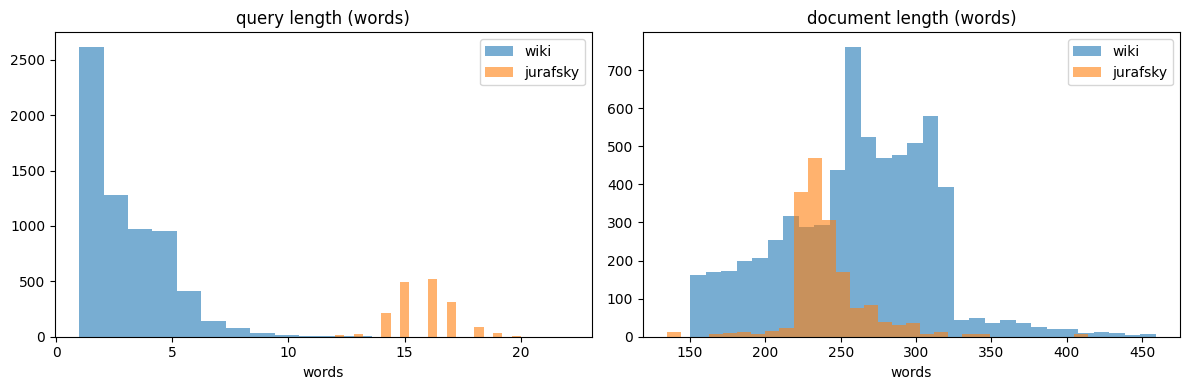

jurafsky query: mean 15.7  min 12  max 20
wiki query : mean 3.3  min 1  max 22
jurafsky doc  : mean 240.2  min 135  max 414
wiki doc   : mean 261.2  min 150  max 459


In [5]:
import matplotlib.pyplot as plt

def wc(s): return len(s.split())

jur_q, wiki_q = [wc(p['query']) for p in jur], [wc(p['query']) for p in wiki]
jur_d, wiki_d = [wc(p['positive_text']) for p in jur], [wc(p['positive_text']) for p in wiki]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(wiki_q, bins=20, alpha=0.6, label='wiki')
ax[0].hist(jur_q,  bins=20, alpha=0.6, label='jurafsky')
ax[0].set_title('query length (words)'); ax[0].set_xlabel('words'); ax[0].legend()
ax[1].hist(wiki_d, bins=30, alpha=0.6, label='wiki')
ax[1].hist(jur_d,  bins=30, alpha=0.6, label='jurafsky')
ax[1].set_title('document length (words)'); ax[1].set_xlabel('words'); ax[1].legend()
plt.tight_layout(); plt.savefig('checkpoints/pair_length_dist.png', dpi=120); plt.show()

def stat(name, xs): print(f'{name}: mean {sum(xs)/len(xs):.1f}  min {min(xs)}  max {max(xs)}')
stat('jurafsky query', jur_q); stat('wiki query ', wiki_q)
stat('jurafsky doc  ', jur_d); stat('wiki doc   ', wiki_d)

## 3. Manual read
Read random pairs and judge: does the document actually answer the query?

In [6]:
import random
rng = random.Random(0)
print('- JURAFSKY pairs')
for p in rng.sample(jur, 4):
    print('Q:', p['query'])
    print('  ', p['positive_id'], '|', p['positive_text'][:160], '...')
    print()
print('- WIKIPEDIA pairs')
for p in rng.sample(wiki, 4):
    print('Q:', p['query'])
    print('  ', p['positive_id'], '|', p['positive_text'][:160], '...')
    print()

- JURAFSKY pairs
Q: What conditional lookup notation extracts initial string segments exclusively when they bypass specific starting letters?
   chunk_0025 | The operator (?! pattern) only returns true if a pattern does not match, but again is zero-width and doesn’t advance the pointer. Negative lookahead is commonly ...

Q: How is the linear combination function translated vectorially using standard matrix dot product notation inside networks?
   chunk_0298 | A unit takes a set of real valued numbers as input, performs some computation on them, and produces an output. At its heart, a neural unit is taking a weighted  ...

Q: Which weighting function is widely used to alter cell counts inside sparse word-context representation matrices?
   chunk_0246 | The vector for digital is outlined in red. Note that a real vector would have vastly more dimensions and thus be much sparser, i.e. would have zero values in mo ...

Q: How is the cosine similarity between a search query and text records

## 4. Duplicate pair check
Same (query, document) twice is wasted training signal. I dropped duplicate wiki chunks at build time, so this should be aorund 0

In [7]:
def dup_check(pairs, name):
    seen, dups = set(), 0
    for p in pairs:
        k = (p['query'], p['positive_id'])
        if k in seen: dups += 1
        seen.add(k)
    print(f'{name}: {dups} duplicate (query, positive_id) pairs out of {len(pairs)}')

dup_check(jur, 'jurafsky ')
dup_check(wiki, 'wikipedia')
# also: empty / whitespace-only fields
bad = sum(1 for p in combined if not p['query'].strip() or not p['positive_text'].strip())
print('empty query or document:', bad)

jurafsky : 1140 duplicate (query, positive_id) pairs out of 1710
wikipedia: 0 duplicate (query, positive_id) pairs out of 6527
empty query or document: 0


## 5. Why LLM questions and not first sentences

In our old approach used each chunks first sentence as its query. That teaches
the model to match identical text instead of meaning.
Below we show that the LLM query uses different words than the chunk it answers, which is
what forces the model to learn semantic similarity (the whole point of a
neural search engine over BM25).

In [8]:

sample = jur[0]
q_words = set(sample['query'].lower().split())
d_words = set(sample['positive_text'].lower().split())
overlap = q_words & d_words
print('QUERY :', sample['query'])
print('DOC :', sample['positive_text'][:200], '...')
print()
print(f'query words: {len(q_words)} | shared with doc: {len(overlap)} '
      f'({len(overlap)/len(q_words):.0%})')
print('- low overlap means the model cannot win by keyword matching alone')

QUERY : What historical privacy concerns were raised during early experiments with Joseph Weizenbaum's therapeutic ELIZA chatbot?
DOC : They found, for example, that simple changes like using the word ‘she’ instead of ‘he’ in a sentence caused systems to respond more offensively and with more negative sentiment. Hofmann et al. (2024)  ...

query words: 15 | shared with doc: 4 (27%)
- low overlap means the model cannot win by keyword matching alone


## 6. In-batch negatives and false negatives

We train with InfoNCE, so for each query the "negatives" are the other positives
in the same batch (63 of them at batch size 64). The batch is filled by random
shuffling, so a few of those 63 might not really be negative:

- wikipedia: we make 2 pairs per article, so two pairs can share the same article.
  if both land in the same batch, one's positive is used as the other's negative,
  but they are from the same article so actually related.
- jurafsky: the LLM writes 2 questions per chunk, so the same chunk is the positive
  of 2 different pairs. if those collide in a batch it is even tighter, the exact
  same chunk text gets treated as a negative for the other query.

so these are false negatives. the cell below measures how often two such pairs would land in the same batch. it turns out to be small (under
1% of negatives) because each batch still has about 62 real negatives that dominate.

decision: we keep all the data and document this as a known limitation instead of
shrinking the dataset. dropping to 1 pair per article/chunk would remove the
collision but also throws away pairs and our templated question queries for a tiny
gain. the proper fix for future work if we have time is false negative masking: pass each pair's
source id into the loss and set same-source similarities to -inf so they are never
counted as negatives.

In [11]:
from collections import Counter
from math import comb

# sibling is another pair with the same source. jurafsky siblings share the exact positive_id (2 questions per chunk). wiki siblings share the article.
jur_counts = Counter(p['positive_id'] for p in jur)
jur_sib = sum(1 for p in jur if jur_counts[p['positive_id']] > 1)

wiki_chunks = load('data/wiki/wiki_chunks.json')
id2art = {c['id']: c['source_title'] for c in wiki_chunks}
arts = [id2art.get(p['positive_id']) for p in wiki]
art_counts = Counter(a for a in arts if a is not None)
wiki_sib = sum(1 for a in arts if a is not None and art_counts[a] > 1)

print(f'jurafsky pairs with a same-chunk sibling : {jur_sib} / {len(jur)}')
print(f'wiki pairs with a same-article sibling   : {wiki_sib} / {len(wiki)}')

# how often do two siblings actually land in the same batch
N = len(combined)
B = 64
p_collide = (B - 1) / (N - 1) # chance a given sibling shares this pair's batch

sib_pairs = sum(comb(c, 2) for c in jur_counts.values()) + sum(comb(c, 2) for c in art_counts.values())
exp_per_epoch = sib_pairs * p_collide
n_batches = N // B

print(f'prob two siblings share a batch : {p_collide:.3%}')
print(f'false-negative collisions per epoch : {exp_per_epoch:.1f} over {n_batches} batches')
print(f'false negatives per batch : {exp_per_epoch / n_batches:.2f} out of {B-1}')
print(f'= roughly {exp_per_epoch / n_batches / (B-1):.2%} of the negatives in a batch')

jurafsky pairs with a same-chunk sibling : 1710 / 1710
wiki pairs with a same-article sibling   : 5430 / 6527
prob two siblings share a batch : 0.765%
false-negative collisions per epoch : 51.5 over 128 batches
false negatives per batch : 0.40 out of 63
= roughly 0.64% of the negatives in a batch


## Summary

- documents on both sources sit in the 200-300 word target range
- jurafsky queries are full natural-language questions (8-20 words),
  wiki queries are short titles / templated questions
- no duplicate pairs, no empty fields
- all pairs are positives only, InfoNCE supplies in batch negatives
- in-batch negatives can include a few false negatives (<1%), kept and
  documented in section 6 rather than fixed by shrinking the data
- wiki cleaning removed 580 duplicate chunks, 682 reference-list chunks and
  217 off-topic articles before pairing (see docs/05_WIKI_DATA_INTEGRATION.md)